# Telco Customer Churn for Marketing Retention

## Beginner-friendly summary
This notebook builds and compares churn models, checks probability quality, connects model output to business decisions, and adds uplift-style measurement logic.

### What this notebook does
- Loads and cleans telco customer data
- Builds baseline and improved predictive models (Logistic Regression and XGBoost)
- Evaluates model quality (ROC-AUC, PR-AUC, log loss, learning behavior)
- Calibrates probabilities so risk scores are more trustworthy
- Tunes decision thresholds with cost and ROI context
- Adds explainability (feature importance / SHAP)
- Adds risk segmentation (for example, top 20% high-risk capture)
- Adds uplift modeling components and incremental-impact evaluation

### Major steps (in order)
1. Setup and data loading
2. Data preparation and feature engineering
3. Baseline modeling
4. Improved modeling and imbalance handling
5. Calibration and diagnostics
6. Thresholding and business metrics
7. Explainability and segmentation
8. Uplift / incremental impact analysis
9. Final checklist and conclusions

### Side notes for beginners
- A high AUC means better ranking, not automatically good probability values.
- Calibration answers: “When model says 0.7, does reality look close to 70%?”
- Threshold is a business decision rule, not a fixed model truth.
- Uplift focuses on incremental change caused by treatment, not just conversion prediction.


## Recommended Run Order (Deterministic)

To avoid stale globals and metric mismatch, run cells in this sequence:

1. Setup + Load + Clean + EDA
2. Baseline Logistic + XGBoost baseline
3. Class imbalance handling (`scale_pos_weight`)
4. Probability calibration (this sets canonical `final_scoring_proba`)
5. Threshold optimization + ROI/profit + risk top-20% capture
6. SHAP explainability
7. Uplift modeling sections (demo-only if treatment/outcome are synthetic)
8. MLflow logging (run near the end so it captures final metrics)

Best practice: `Kernel -> Restart & Run All` before final outputs you plan to share.


## Setup

If `xgboost` is missing in this environment, uncomment the install command below and run it once.


In [1]:
# %pip install xgboost seaborn scikit-learn matplotlib pandas numpy

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


/usr/local/lib/python3.8/dist-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


## Step 1: Load Data

Place `Telco-Customer-Churn.csv` in `data/` under this notebooks folder, or update `DATA_PATH` below.


In [2]:
DATA_PATH = Path("data/Telco-Customer-Churn.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.resolve()}. Add the dataset to the notebooks folder or update DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 2: Basic Cleaning

We convert the target to binary, fix `TotalCharges`, and remove rows where the charge value is missing after conversion.


In [3]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna().copy()

print(df.shape)
df.head()


(7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Step 3: EDA

A few project-friendly checks:

- What is the churn rate?
- Is the dataset imbalanced?
- Which business variables look associated with churn?


Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


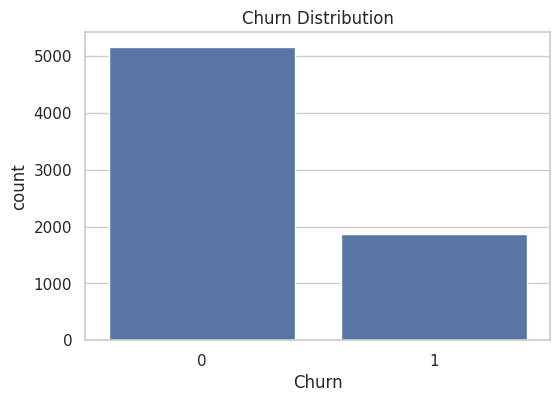

Average MonthlyCharges by churn:
Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64


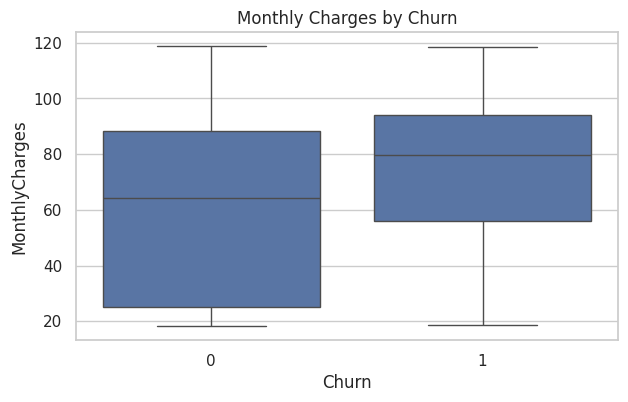

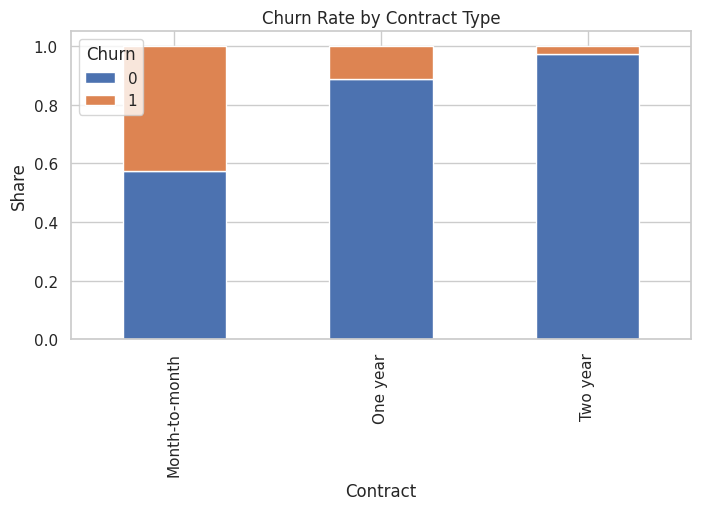

In [4]:
churn_rate = df["Churn"].value_counts(normalize=True).sort_index()
print(churn_rate)

plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

print("Average MonthlyCharges by churn:")
print(df.groupby("Churn")["MonthlyCharges"].mean())

plt.figure(figsize=(7, 4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn")
plt.show()

plt.figure(figsize=(8, 4))
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index")
contract_churn.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Churn Rate by Contract Type")
plt.ylabel("Share")
plt.legend(title="Churn")
plt.show()


### Key talking points

- The dataset is typically imbalanced, with churn materially lower than non-churn.
- Higher `MonthlyCharges` often correlate with more churn risk.
- Month-to-month contracts tend to show meaningfully higher churn than long-term contracts.
- These patterns support targeted retention offers for high-risk, high-value customers.


## Step 4: Feature Engineering

We drop `customerID`, then keep numeric and categorical columns separate so we can use preprocessing pipelines cleanly.


In [5]:
df = df.drop("customerID", axis=1)

X = df.drop("Churn", axis=1)
y = df["Churn"]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


## Step 5: Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(X_train.shape, X_test.shape)


(5625, 19) (1407, 19)


## Step 6: Logistic Regression Baseline

We start with a simple and interpretable baseline so we can compare it against stronger versions later.


In [7]:
lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)

lr_model.fit(X_train, y_train)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]


## Step 6b: Logistic Regression v2 (Feature Engineering + CV Tuning)

Beginner side notes:
- Logistic Regression is linear by default, so it can miss curved/nonlinear patterns.
- We add a few engineered features (log, square, interaction) to help it learn richer behavior.
- We tune regularization strength (`C`) with cross-validation using **log loss**.
- Lower log loss means better probability quality.


In [8]:
# Side note (beginner): this block upgrades baseline logistic regression while keeping the model family simple.

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import log_loss, brier_score_loss


def add_lr_v2_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add light nonlinear signals for Logistic Regression."""
    out = df.copy()

    if 'tenure' in out.columns:
        out['tenure_log1p'] = np.log1p(out['tenure'].astype(float))

    if 'MonthlyCharges' in out.columns:
        mc = out['MonthlyCharges'].astype(float)
        out['monthlycharges_sq'] = mc ** 2

    if {'tenure', 'MonthlyCharges'}.issubset(out.columns):
        out['tenure_x_monthlycharges'] = out['tenure'].astype(float) * out['MonthlyCharges'].astype(float)

    if {'TotalCharges', 'tenure'}.issubset(out.columns):
        denom = out['tenure'].astype(float).replace(0, 1)
        out['avg_charge_per_tenure'] = out['TotalCharges'].astype(float) / denom

    return out


X_train_lr2 = add_lr_v2_features(X_train)
X_test_lr2 = add_lr_v2_features(X_test)

numeric_features_lr2 = X_train_lr2.select_dtypes(include=['number']).columns.tolist()
categorical_features_lr2 = [c for c in X_train_lr2.columns if c not in numeric_features_lr2]

numeric_transformer_lr2 = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)

categorical_transformer_lr2 = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')),
    ]
)

preprocessor_lr2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_lr2, numeric_features_lr2),
        ('cat', categorical_transformer_lr2, categorical_features_lr2),
    ]
)

lr_v2_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor_lr2),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)),
    ]
)

# Side note (beginner): C controls regularization strength.
# Smaller C => stronger regularization; larger C => weaker regularization.
param_grid = {
    'model__C': [0.05, 0.1, 0.5, 1.0, 2.0],
}

lr_v2_search = GridSearchCV(
    estimator=lr_v2_pipeline,
    param_grid=param_grid,
    scoring='neg_log_loss',
    cv=3,
    n_jobs=1,
    refit=True,
)

lr_v2_search.fit(X_train_lr2, y_train)
lr_model_v2 = lr_v2_search.best_estimator_
y_pred_proba_lr2 = lr_model_v2.predict_proba(X_test_lr2)[:, 1]

print('Best LR v2 params:', lr_v2_search.best_params_)

lr_compare = pd.DataFrame([
    {
        'model': 'Logistic Regression (baseline)',
        'roc_auc': roc_auc_score(y_test, y_pred_proba_lr),
        'pr_auc': average_precision_score(y_test, y_pred_proba_lr),
        'log_loss': log_loss(y_test, y_pred_proba_lr),
        'brier': brier_score_loss(y_test, y_pred_proba_lr),
    },
    {
        'model': 'Logistic Regression v2',
        'roc_auc': roc_auc_score(y_test, y_pred_proba_lr2),
        'pr_auc': average_precision_score(y_test, y_pred_proba_lr2),
        'log_loss': log_loss(y_test, y_pred_proba_lr2),
        'brier': brier_score_loss(y_test, y_pred_proba_lr2),
    },
]).sort_values('log_loss')

display(lr_compare.style.format({
    'roc_auc': '{:.4f}',
    'pr_auc': '{:.4f}',
    'log_loss': '{:.4f}',
    'brier': '{:.4f}',
}))


Best LR v2 params: {'model__C': 2.0}


,model,roc_auc,pr_auc,log_loss,brier
0,Logistic Regression (baseline),0.8361,0.6230,0.4273,0.1400
1,Logistic Regression v2,0.8389,0.6535,0.5038,0.1711


## Step 6c: Calibrate Logistic Regression v2 Probabilities

Beginner side notes:
- A model can rank customers well but still output probabilities that are too high/low.
- Calibration adjusts the probability scale so scores are closer to real-world frequencies.
- We compare two common calibration methods:
  - Platt scaling (`sigmoid`)
  - Isotonic calibration (`isotonic`)
- We use **log loss** and **brier score** to pick the better calibrated LR v2 output.


In [9]:
# Side note (beginner): calibrate on a held-out split from training data,
# then evaluate on the unchanged test set.

from sklearn.calibration import CalibratedClassifierCV

X_train_lr2_fit, X_cal_lr2, y_train_lr2_fit, y_cal_lr2 = train_test_split(
    X_train_lr2,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train,
)

best_c_lr2 = lr_v2_search.best_params_['model__C']

lr_v2_base_for_cal = Pipeline(
    steps=[
        ('preprocessor', preprocessor_lr2),
        ('model', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            random_state=42,
            C=best_c_lr2,
        )),
    ]
)

lr_v2_base_for_cal.fit(X_train_lr2_fit, y_train_lr2_fit)
y_pred_proba_lr2_raw = lr_v2_base_for_cal.predict_proba(X_test_lr2)[:, 1]

lr_v2_platt = CalibratedClassifierCV(estimator=lr_v2_base_for_cal, method='sigmoid', cv='prefit')
lr_v2_platt.fit(X_cal_lr2, y_cal_lr2)
y_pred_proba_lr2_platt = lr_v2_platt.predict_proba(X_test_lr2)[:, 1]

lr_v2_isotonic = CalibratedClassifierCV(estimator=lr_v2_base_for_cal, method='isotonic', cv='prefit')
lr_v2_isotonic.fit(X_cal_lr2, y_cal_lr2)
y_pred_proba_lr2_isotonic = lr_v2_isotonic.predict_proba(X_test_lr2)[:, 1]

lr2_calibration_compare = pd.DataFrame([
    {
        'model': 'LR baseline',
        'roc_auc': roc_auc_score(y_test, y_pred_proba_lr),
        'pr_auc': average_precision_score(y_test, y_pred_proba_lr),
        'log_loss': log_loss(y_test, y_pred_proba_lr),
        'brier': brier_score_loss(y_test, y_pred_proba_lr),
    },
    {
        'model': 'LR v2 (raw)',
        'roc_auc': roc_auc_score(y_test, y_pred_proba_lr2_raw),
        'pr_auc': average_precision_score(y_test, y_pred_proba_lr2_raw),
        'log_loss': log_loss(y_test, y_pred_proba_lr2_raw),
        'brier': brier_score_loss(y_test, y_pred_proba_lr2_raw),
    },
    {
        'model': 'LR v2 + Platt',
        'roc_auc': roc_auc_score(y_test, y_pred_proba_lr2_platt),
        'pr_auc': average_precision_score(y_test, y_pred_proba_lr2_platt),
        'log_loss': log_loss(y_test, y_pred_proba_lr2_platt),
        'brier': brier_score_loss(y_test, y_pred_proba_lr2_platt),
    },
    {
        'model': 'LR v2 + Isotonic',
        'roc_auc': roc_auc_score(y_test, y_pred_proba_lr2_isotonic),
        'pr_auc': average_precision_score(y_test, y_pred_proba_lr2_isotonic),
        'log_loss': log_loss(y_test, y_pred_proba_lr2_isotonic),
        'brier': brier_score_loss(y_test, y_pred_proba_lr2_isotonic),
    },
]).sort_values('log_loss').reset_index(drop=True)

display(lr2_calibration_compare.style.format({
    'roc_auc': '{:.4f}',
    'pr_auc': '{:.4f}',
    'log_loss': '{:.4f}',
    'brier': '{:.4f}',
}))

best_lr2_row = lr2_calibration_compare.iloc[0]
best_lr2_model_name = best_lr2_row['model']
if best_lr2_model_name == 'LR v2 + Platt':
    y_pred_proba_lr2_calibrated = y_pred_proba_lr2_platt
elif best_lr2_model_name == 'LR v2 + Isotonic':
    y_pred_proba_lr2_calibrated = y_pred_proba_lr2_isotonic
else:
    y_pred_proba_lr2_calibrated = y_pred_proba_lr2_raw

print('Selected LR v2 probability output for calibration quality:', best_lr2_model_name)


,model,roc_auc,pr_auc,log_loss,brier
0,LR v2 + Platt,0.8383,0.6539,0.4240,0.1388
1,LR baseline,0.8361,0.6230,0.4273,0.1400
2,LR v2 + Isotonic,0.8371,0.6345,0.4497,0.1404
3,LR v2 (raw),0.8383,0.6539,0.5017,0.1700


Selected LR v2 probability output for calibration quality: LR v2 + Platt


## Step 6d: Bootstrap Significance Check (Baseline LR vs Calibrated LR v2)

Beginner side notes:
- Small metric gains can happen by chance on one test split.
- Bootstrapping re-samples the test set many times to estimate uncertainty.
- We compute confidence intervals for metric improvement:
  - `delta_log_loss = baseline - calibrated` (positive is better)
  - `delta_brier = baseline - calibrated` (positive is better)
- If the 95% interval stays above zero, improvement is statistically reliable on this test set.


In [10]:
# Side note (beginner): this checks whether the calibrated LR v2 gain is likely real,
# not just random fluctuation from one split.

rng = np.random.default_rng(42)
n_boot = 2000

y_true_boot = np.asarray(y_test)
p_base_boot = np.asarray(y_pred_proba_lr)
p_new_boot = np.asarray(y_pred_proba_lr2_calibrated)

delta_logloss = np.empty(n_boot)
delta_brier = np.empty(n_boot)

n = len(y_true_boot)
for i in range(n_boot):
    idx = rng.integers(0, n, size=n)
    y_b = y_true_boot[idx]
    pb = p_base_boot[idx]
    pn = p_new_boot[idx]

    # Positive delta means calibrated LR v2 improved over baseline.
    delta_logloss[i] = log_loss(y_b, pb) - log_loss(y_b, pn)
    delta_brier[i] = brier_score_loss(y_b, pb) - brier_score_loss(y_b, pn)

ll_ci = np.percentile(delta_logloss, [2.5, 50, 97.5])
br_ci = np.percentile(delta_brier, [2.5, 50, 97.5])

significant_logloss = ll_ci[0] > 0
significant_brier = br_ci[0] > 0

bootstrap_report = pd.DataFrame([
    {
        'metric': 'log_loss improvement (baseline - calibrated)',
        'median_delta': ll_ci[1],
        'ci95_low': ll_ci[0],
        'ci95_high': ll_ci[2],
        'significant_improvement': significant_logloss,
    },
    {
        'metric': 'brier improvement (baseline - calibrated)',
        'median_delta': br_ci[1],
        'ci95_low': br_ci[0],
        'ci95_high': br_ci[2],
        'significant_improvement': significant_brier,
    },
])

display(bootstrap_report.style.format({
    'median_delta': '{:.6f}',
    'ci95_low': '{:.6f}',
    'ci95_high': '{:.6f}',
}))

overall_verdict = 'significant' if (significant_logloss and significant_brier) else 'not_significant_or_mixed'
print('Bootstrap verdict:', overall_verdict)


,metric,median_delta,ci95_low,ci95_high,significant_improvement
0,log_loss improvement (baseline - calibrated),0.003317,-0.003102,0.009488,False
1,brier improvement (baseline - calibrated),0.001142,-0.001496,0.003780,False


Bootstrap verdict: not_significant_or_mixed


## Step 7: XGBoost Model

We fit XGBoost on an encoded feature matrix so it can handle the transformed inputs directly.


In [11]:
X_train_xgb = pd.get_dummies(X_train, drop_first=True)
X_test_xgb = pd.get_dummies(X_test, drop_first=True)
X_test_xgb = X_test_xgb.reindex(columns=X_train_xgb.columns, fill_value=0)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
)

xgb_model.fit(X_train_xgb, y_train)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]


## Step 8: Evaluation

For imbalanced churn problems, ROC-AUC is useful, but PR-AUC is especially important because it reflects how well we rank likely churners.


In [12]:
print("LR ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba_lr), 4))
print("XGB ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba_xgb), 4))
print("LR PR-AUC:", round(average_precision_score(y_test, y_pred_proba_lr), 4))
print("XGB PR-AUC:", round(average_precision_score(y_test, y_pred_proba_xgb), 4))


LR ROC-AUC: 0.8361
XGB ROC-AUC: 0.8348
LR PR-AUC: 0.623
XGB PR-AUC: 0.6479


In [13]:
# globals()

## Step 9: Threshold Optimization

Instead of using the default threshold of `0.5`, we lower it to capture more churners. This is a business decision: higher recall can be more valuable when missing a churner is expensive.


In [14]:
# Use one canonical score path so thresholding, ROI, and tracking stay consistent.
if 'final_scoring_proba' not in globals():
    final_scoring_proba = y_pred_proba_xgb_balanced if 'y_pred_proba_xgb_balanced' in globals() else y_pred_proba_xgb
    final_scoring_label = 'xgb_balanced_fallback' if 'y_pred_proba_xgb_balanced' in globals() else 'xgb_baseline_fallback'

threshold = 0.30
y_pred = (final_scoring_proba > threshold).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))


[[760 273]
 [ 84 290]]
              precision    recall  f1-score   support

           0      0.900     0.736     0.810      1033
           1      0.515     0.775     0.619       374

    accuracy                          0.746      1407
   macro avg      0.708     0.756     0.714      1407
weighted avg      0.798     0.746     0.759      1407



In [15]:
# Unit checks: verify scoring path, thresholding, and label tracking are aligned.
import numpy as np

assert 'final_scoring_proba' in globals(), "final_scoring_proba is missing"
assert 'final_scoring_label' in globals(), "final_scoring_label is missing"

final_scoring_proba_arr = np.asarray(final_scoring_proba)
y_test_arr = np.asarray(y_test)

assert final_scoring_proba_arr.shape[0] == y_test_arr.shape[0], (
    f"Length mismatch: proba={final_scoring_proba_arr.shape[0]}, y_test={y_test_arr.shape[0]}"
)
assert np.all((final_scoring_proba_arr >= 0) & (final_scoring_proba_arr <= 1)), "Probabilities must be in [0,1]"

allowed_labels = {'xgb_baseline_fallback', 'xgb_balanced_fallback', 'xgb_calibrated'}
assert final_scoring_label in allowed_labels, f"Unexpected scoring label: {final_scoring_label}"

y_pred_check = (final_scoring_proba_arr > threshold).astype(int)
assert np.array_equal(np.asarray(y_pred), y_pred_check), "y_pred is not derived from final_scoring_proba + threshold"
assert set(np.unique(y_pred_check)).issubset({0, 1}), "Predictions must be binary {0,1}"

print("Alignment unit checks passed.")
print({
    'scoring_model_used': final_scoring_label,
    'n_test_rows': int(y_test_arr.shape[0]),
    'threshold': float(threshold)
})


Alignment unit checks passed.
{'scoring_model_used': 'xgb_baseline_fallback', 'n_test_rows': 1407, 'threshold': 0.3}


## Step 10: Business Cost Function

Here we define a simple profit logic:

- True Positive: we correctly identify a churner and save them with a retention action
- False Negative: we miss a churner and lose that customer
- False Positive: we offer an unnecessary retention incentive


In [16]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

profit = tp * 100 + tn * 0 + fp * (-10) + fn * (-100)

print({"tn": tn, "fp": fp, "fn": fn, "tp": tp})
print("Profit:", profit)


{'tn': 760, 'fp': 273, 'fn': 84, 'tp': 290}
Profit: 17870


### Optional: search for the best threshold by business value

This is often stronger than manually picking `0.30` because it shows decision optimization, not just model fitting.


In [17]:
if 'final_scoring_proba' not in globals():
    final_scoring_proba = y_pred_proba_xgb_balanced if 'y_pred_proba_xgb_balanced' in globals() else y_pred_proba_xgb
    final_scoring_label = 'xgb_balanced_fallback' if 'y_pred_proba_xgb_balanced' in globals() else 'xgb_baseline_fallback'

threshold_results = []

for t in np.arange(0.10, 0.91, 0.05):
    preds = (final_scoring_proba > t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, preds).ravel()
    profit_ = tp_ * 100 + fp_ * (-10) + fn_ * (-100)
    threshold_results.append(
        {
            "threshold": round(float(t), 2),
            "tp": tp_,
            "fp": fp_,
            "fn": fn_,
            "profit": profit_,
        }
    )

threshold_df = pd.DataFrame(threshold_results).sort_values("profit", ascending=False).reset_index(drop=True)
best_threshold = float(threshold_df.loc[0, 'threshold'])
best_profit = float(threshold_df.loc[0, 'profit'])
final_scoring_threshold = best_threshold
threshold_df.head(10)


,threshold,tp,fp,fn,profit
0,0.10,351,525,23,27550
1,0.15,331,421,43,24590
2,0.20,314,370,60,21700
3,0.25,302,316,72,19840
4,0.30,290,273,84,17870
5,0.35,272,229,102,14710
6,0.40,247,175,127,10250
7,0.45,225,147,149,6130
8,0.50,198,114,176,1060
9,0.55,173,92,201,-3720


## Step 11: Feature Importance

This helps connect the model back to marketing strategy and customer retention actions.


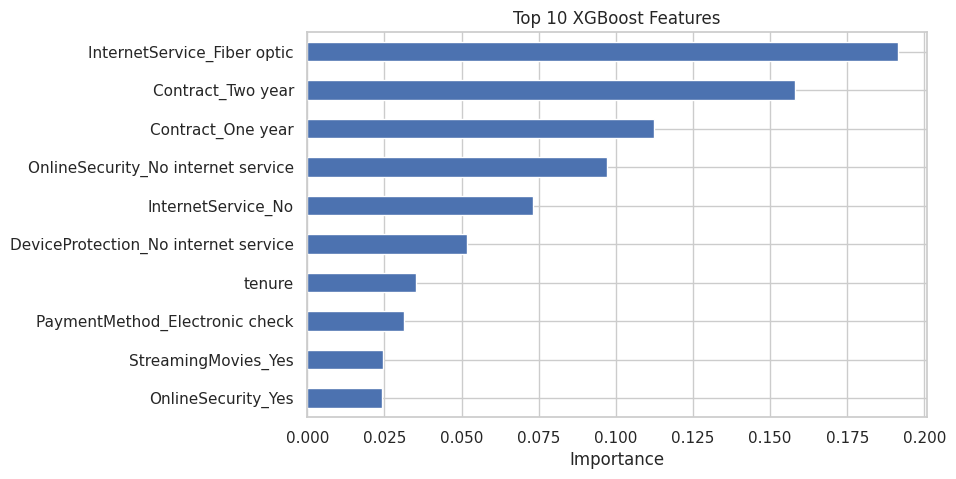

OnlineSecurity_Yes                      0.024354
StreamingMovies_Yes                     0.024569
PaymentMethod_Electronic check          0.031512
tenure                                  0.035272
DeviceProtection_No internet service    0.051790
InternetService_No                      0.073071
OnlineSecurity_No internet service      0.097204
Contract_One year                       0.112522
Contract_Two year                       0.158184
InternetService_Fiber optic             0.191326
dtype: float32

In [18]:
importances = pd.Series(xgb_model.feature_importances_, index=X_train_xgb.columns)
top_features = importances.sort_values(ascending=False).head(10).sort_values()

plt.figure(figsize=(8, 5))
top_features.plot(kind="barh")
plt.title("Top 10 XGBoost Features")
plt.xlabel("Importance")
plt.show()

top_features


## Step 11B: Class Imbalance Handling (XGBoost)

To make churn detection more robust, we explicitly weight the positive class using `scale_pos_weight = negative / positive`.


In [19]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print({'neg_count': int(neg_count), 'pos_count': int(pos_count), 'scale_pos_weight': round(float(scale_pos_weight), 2)})

xgb_model_balanced = XGBClassifier(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
)

xgb_model_balanced.fit(X_train_xgb, y_train)
y_pred_proba_xgb_balanced = xgb_model_balanced.predict_proba(X_test_xgb)[:, 1]

print('XGB (balanced) ROC-AUC:', round(roc_auc_score(y_test, y_pred_proba_xgb_balanced), 4))
print('XGB (balanced) PR-AUC:', round(average_precision_score(y_test, y_pred_proba_xgb_balanced), 4))


{'neg_count': 4130, 'pos_count': 1495, 'scale_pos_weight': 2.76}


XGB (balanced) ROC-AUC: 0.8329
XGB (balanced) PR-AUC: 0.6482


## Step 11C: Probability Calibration

AUC measures ranking quality. Calibration checks whether predicted probabilities are trustworthy for business decisioning.


> **Side note (calibration method choice):**
> - **Isotonic** is flexible and often better when you have enough data.
> - **Platt scaling** (`method="sigmoid"`) is more stable on smaller datasets.
> - In practice: mention you would compare both with **Brier score** and pick the more stable holdout result.


In [20]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

xgb_for_calibration = XGBClassifier(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
)

# sklearn compatibility: older versions use `base_estimator`, newer versions use `estimator`.
try:
    calibrated_xgb = CalibratedClassifierCV(
        estimator=xgb_for_calibration,
        method='isotonic',
        cv=3,
    )
except TypeError:
    calibrated_xgb = CalibratedClassifierCV(
        base_estimator=xgb_for_calibration,
        method='isotonic',
        cv=3,
    )

calibrated_xgb.fit(X_train_xgb, y_train)
y_pred_proba_xgb_calibrated = calibrated_xgb.predict_proba(X_test_xgb)[:, 1]

# Canonical score used downstream (thresholding, business ROI, MLflow logging).
final_scoring_proba = y_pred_proba_xgb_calibrated
final_scoring_label = 'xgb_calibrated'

print('Brier (uncalibrated):', round(brier_score_loss(y_test, y_pred_proba_xgb_balanced), 4))
print('Brier (calibrated):', round(brier_score_loss(y_test, y_pred_proba_xgb_calibrated), 4))
print('ROC-AUC (calibrated):', round(roc_auc_score(y_test, y_pred_proba_xgb_calibrated), 4))
print('PR-AUC (calibrated):', round(average_precision_score(y_test, y_pred_proba_xgb_calibrated), 4))


Brier (uncalibrated): 0.1697
Brier (calibrated): 0.1392
ROC-AUC (calibrated): 0.8368
PR-AUC (calibrated): 0.6506


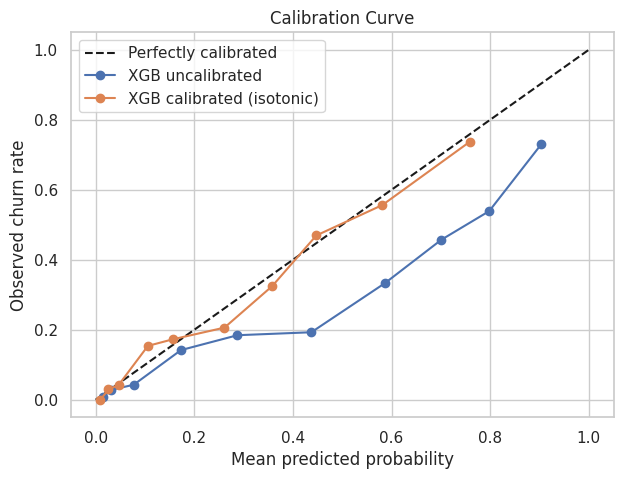

In [21]:
prob_true_uncal, prob_pred_uncal = calibration_curve(y_test, y_pred_proba_xgb_balanced, n_bins=10, strategy='quantile')
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_pred_proba_xgb_calibrated, n_bins=10, strategy='quantile')

plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.plot(prob_pred_uncal, prob_true_uncal, marker='o', label='XGB uncalibrated')
plt.plot(prob_pred_cal, prob_true_cal, marker='o', label='XGB calibrated (isotonic)')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed churn rate')
plt.title('Calibration Curve')
plt.legend()
plt.show()


## Step 11D: SHAP Explainability

SHAP provides local and global explanations for why customers are scored as likely churners.


> **Side note (SHAP caveat):**
> SHAP explains *model behavior* (associations learned by the model), not causal effect.
> Use it to support action design, but validate interventions with experiments or controlled rollouts.


In [22]:
!pip install shap

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


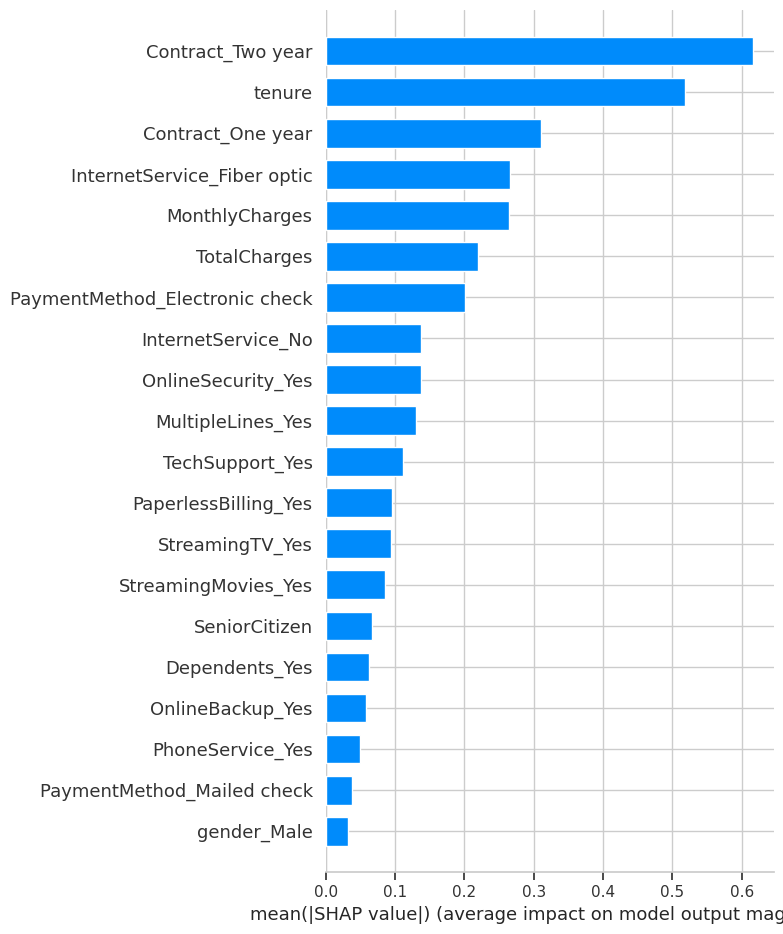

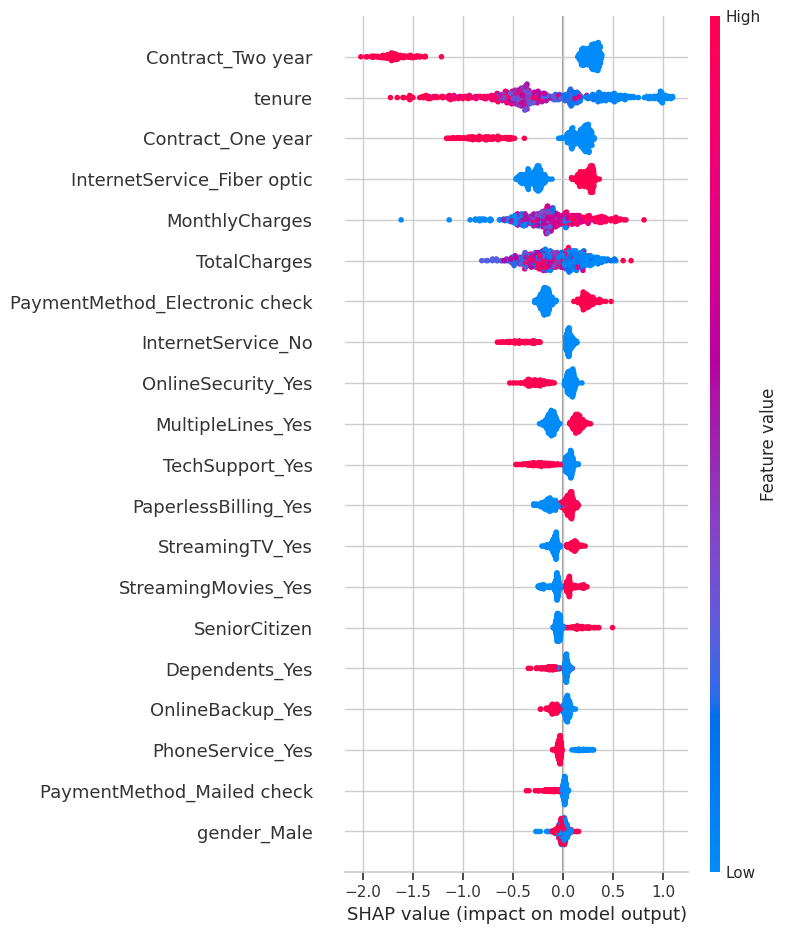

Contract_Two year                 0.615782
tenure                            0.517505
Contract_One year                 0.309960
InternetService_Fiber optic       0.265195
MonthlyCharges                    0.264083
TotalCharges                      0.219167
PaymentMethod_Electronic check    0.200282
InternetService_No                0.137693
OnlineSecurity_Yes                0.137429
MultipleLines_Yes                 0.129386
TechSupport_Yes                   0.111548
PaperlessBilling_Yes              0.095951
StreamingTV_Yes                   0.094430
StreamingMovies_Yes               0.085228
SeniorCitizen                     0.066888
Name: mean_abs_shap, dtype: float32

In [23]:
# If SHAP is not installed in your notebook environment, uncomment and run once:

try:
    import shap

    shap_sample = X_test_xgb.sample(n=min(500, len(X_test_xgb)), random_state=42)
    explainer = shap.TreeExplainer(xgb_model_balanced)
    shap_output = explainer(shap_sample)

    # Compatibility across SHAP versions: Explanation object vs raw ndarray/list.
    if hasattr(shap_output, 'values'):
        shap_values_raw = shap_output.values
        shap.summary_plot(shap_output, shap_sample, plot_type='bar', show=True)
        shap.summary_plot(shap_output, shap_sample, show=True)
    else:
        shap_values_raw = shap_output
        shap.summary_plot(shap_values_raw, shap_sample, plot_type='bar', show=True)
        shap.summary_plot(shap_values_raw, shap_sample, show=True)

    # Beginner-friendly global importance table (mean absolute SHAP impact).
    if isinstance(shap_values_raw, list):
        shap_arr = shap_values_raw[1] if len(shap_values_raw) > 1 else shap_values_raw[0]
    else:
        shap_arr = shap_values_raw

    shap_importance = pd.Series(np.abs(shap_arr).mean(axis=0), index=shap_sample.columns).sort_values(ascending=False)
    display(shap_importance.head(15).rename('mean_abs_shap'))
except ModuleNotFoundError:
    print('SHAP is not installed. Run `%pip install shap` and rerun this cell.')


## Step 11E: Risk Segmentation (Top 20% Capture)

We rank customers by churn probability and check what fraction of true churners is captured in the top-risk segment.


> **Side note (business interpretation):**
> `capture_rate_top20pct` answers: *"If operations can only target 20% of customers, what share of all churners do we catch?"*
> This ties model ranking directly to campaign capacity and expected retention impact.


In [24]:
score_col = 'score_calibrated'
scores_for_segmentation = final_scoring_proba if 'final_scoring_proba' in globals() else (y_pred_proba_xgb_calibrated if 'y_pred_proba_xgb_calibrated' in globals() else y_pred_proba_xgb_balanced)

risk_df = X_test.copy().reset_index(drop=True)
risk_df[score_col] = scores_for_segmentation
risk_df['actual_churn'] = y_test.reset_index(drop=True)

risk_df = risk_df.sort_values(score_col, ascending=False).reset_index(drop=True)
top_n = max(1, int(len(risk_df) * 0.20))
top_segment = risk_df.head(top_n)

total_churners = int(risk_df['actual_churn'].sum())
captured_churners = int(top_segment['actual_churn'].sum())
capture_rate = captured_churners / total_churners if total_churners > 0 else 0

print({'top_segment_size': top_n, 'total_churners': total_churners, 'captured_churners_top20pct': captured_churners, 'capture_rate_top20pct': round(capture_rate, 4)})

display_cols = [c for c in ['tenure', 'Contract', 'MonthlyCharges', 'TotalCharges', score_col, 'actual_churn'] if c in top_segment.columns]
top_segment[display_cols].head(15)


{'top_segment_size': 281, 'total_churners': 374, 'captured_churners_top20pct': 184, 'capture_rate_top20pct': 0.492}


,tenure,Contract,MonthlyCharges,TotalCharges,score_calibrated,actual_churn
0,1,Month-to-month,95.10,95.10,0.990991,1
1,1,Month-to-month,85.05,85.05,0.990991,1
2,3,Month-to-month,100.95,329.95,0.863566,1
3,3,Month-to-month,96.60,291.90,0.861857,1
4,1,Month-to-month,77.15,77.15,0.861857,1
5,7,Month-to-month,99.25,665.45,0.861857,1
6,4,Month-to-month,89.20,346.20,0.858500,1
7,1,Month-to-month,79.35,79.35,0.854557,1
8,3,Month-to-month,94.85,335.75,0.852847,0
9,3,Month-to-month,85.30,264.80,0.844595,1


## Step 11F: Leakage And Overfitting Check

We compare train vs. test AUC. Large gaps can indicate overfitting, and we also keep an explicit statement on leakage control.


> **Side note (threshold governance):**
> The chosen threshold should be reviewed regularly (for example monthly/quarterly) because churn base rates, campaign cost, and incentive effectiveness change over time.


In [25]:
# Train vs test gap checks
lr_train_proba = lr_model.predict_proba(X_train)[:, 1]
lr_test_proba = y_pred_proba_lr

xgb_train_proba = xgb_model_balanced.predict_proba(X_train_xgb)[:, 1]
xgb_test_proba = y_pred_proba_xgb_balanced

train_test_auc = pd.DataFrame(
    {
        'model': ['LogisticRegression', 'XGBoostBalanced'],
        'train_roc_auc': [roc_auc_score(y_train, lr_train_proba), roc_auc_score(y_train, xgb_train_proba)],
        'test_roc_auc': [roc_auc_score(y_test, lr_test_proba), roc_auc_score(y_test, xgb_test_proba)],
    }
)
train_test_auc['auc_gap'] = train_test_auc['train_roc_auc'] - train_test_auc['test_roc_auc']
train_test_auc.round(4)


,model,train_roc_auc,test_roc_auc,auc_gap
0,LogisticRegression,0.8506,0.8361,0.0145
1,XGBoostBalanced,0.9050,0.8329,0.0722


### Interpretation: Generalization Gap

- Logistic Regression gap is small, which suggests more stable generalization.
- XGBoost gap is larger, which is expected with higher flexibility and indicates higher overfitting risk.
- Practical action: keep XGBoost but monitor complexity (depth, estimators, regularization) and tune on validation / cross-validation.

project-ready line:

> XGBoost improves flexibility but shows a bigger train-test gap, so I would monitor complexity and use validation tuning.


### Leakage control note

Leakage check used in this notebook:
- Features are based on customer attributes available at scoring time.
- `Churn` is only used as the target label and is excluded from input features.
- Train-test split is done before model fitting, and all metrics are reported on holdout test data.


> **Side note (common leakage traps):**
> - Post-churn events or outcomes embedded in features.
> - Aggregations computed with future data windows.
> - Features that are administrative proxies for cancellation status.


## Reproducibility Note (DVC)

For production-style data and experiment versioning, add DVC to this workflow:
- DVC Quick Start: https://doc.dvc.org/start


> **Side note (monitoring in production):**
> In addition to model metrics, monitor:
> - **Calibration drift** (probability quality decay),
> - **Class balance drift** (churn prevalence shift),
> - **Feature distribution drift** on key drivers.


## Step 11G: Uplift Modeling (Next Level)

Uplift modeling estimates **incremental impact of treatment** (for example, a retention offer) instead of only predicting churn risk.

In this notebook:
- If treatment/outcome columns exist, we use them directly.
- Otherwise, we build a **clearly labeled synthetic demo** so the uplift workflow is still project-ready.


> **Beginner note:**
> Think of uplift as **"who should we contact"** rather than **"who is risky"**.
> A high-risk customer may still be a poor target if treatment does not change their behavior.


> **Side note (context framing):**
> Risk modeling answers *"who will churn?"*.
> Uplift modeling answers *"who will change behavior if we intervene?"*.
> Prioritize outreach by uplift score when campaign budget is limited.


In [26]:
# Auto-detect treatment and outcome columns; prefer real uplift data, fallback to synthetic demo only if needed
from pathlib import Path

possible_treatment_cols = ['treatment', 'is_treated', 'offer', 'retention_offer', 'campaign_flag']
possible_outcome_cols = ['retained', 'conversion', 'responded', 'response', 'visit', 'churn', 'Churn']

treatment_col = next((c for c in possible_treatment_cols if c in df.columns), None)
outcome_col = next((c for c in possible_outcome_cols if c in df.columns), None)

uplift_df = None
uplift_data_source = 'observed_data'
is_uplift_demo_only = False

if treatment_col is not None and outcome_col is not None:
    print(f'Using observed uplift columns from current dataset: treatment={treatment_col}, outcome={outcome_col}')
    uplift_df = df.copy().reset_index(drop=True)
else:
    hillstrom_candidates = [
        Path('data/hillstrom.csv'),
        Path('data/hillstrom_email_marketing.csv'),
        Path('datasets/hillstrom.csv'),
        Path('datasets/hillstrom_email_marketing.csv'),
    ]
    hillstrom_path = next((p for p in hillstrom_candidates if p.exists()), None)

    if hillstrom_path is not None:
        print(f'No treatment/outcome columns in current dataset. Loading Hillstrom-style uplift data from: {hillstrom_path}')
        hillstrom_raw = pd.read_csv(hillstrom_path)
        hillstrom_df = hillstrom_raw.copy()
        hillstrom_lower = {c.lower(): c for c in hillstrom_df.columns}

        segment_col = hillstrom_lower.get('segment')
        conversion_col = hillstrom_lower.get('conversion')
        visit_col = hillstrom_lower.get('visit')
        spend_col = hillstrom_lower.get('spend')

        if segment_col is None:
            raise ValueError('Hillstrom file found but `segment` column is missing.')

        segment_text = hillstrom_df[segment_col].astype(str).str.lower()
        hillstrom_df['treatment'] = (~segment_text.str.contains('no', na=False)).astype(int)

        if conversion_col is not None:
            hillstrom_df['outcome'] = pd.to_numeric(hillstrom_df[conversion_col], errors='coerce').fillna(0)
            hillstrom_df['outcome'] = (hillstrom_df['outcome'] > 0).astype(int)
        elif visit_col is not None:
            hillstrom_df['outcome'] = pd.to_numeric(hillstrom_df[visit_col], errors='coerce').fillna(0)
            hillstrom_df['outcome'] = (hillstrom_df['outcome'] > 0).astype(int)
        elif spend_col is not None:
            hillstrom_df['outcome'] = pd.to_numeric(hillstrom_df[spend_col], errors='coerce').fillna(0)
            hillstrom_df['outcome'] = (hillstrom_df['outcome'] > 0).astype(int)
        else:
            raise ValueError('Hillstrom file found but none of `conversion`, `visit`, or `spend` columns are available for outcome.')

        treatment_col = 'treatment'
        outcome_col = 'outcome'
        uplift_df = hillstrom_df.reset_index(drop=True)
        uplift_data_source = 'hillstrom_email_marketing'
        is_uplift_demo_only = False
    else:
        print('No treatment/outcome columns detected and no Hillstrom file found. Using synthetic uplift demo for workflow illustration.')
        print('IMPORTANT: Uplift outputs below are DEMO ONLY and must not be used as real causal business evidence.')

        uplift_df = X.copy().reset_index(drop=True)

        # Baseline stay probability from the existing logistic model
        base_churn_prob = lr_model.predict_proba(X)[:, 1]
        base_stay_prob = np.clip(1 - base_churn_prob, 0.01, 0.99)

        # Simulated heterogeneous treatment effect (true uplift) for demonstration
        true_tau = np.full(len(uplift_df), 0.02)
        if 'Contract' in uplift_df.columns:
            true_tau += (uplift_df['Contract'].astype(str).str.contains('Month', case=False, na=False)).astype(float) * 0.08
        if 'MonthlyCharges' in uplift_df.columns:
            true_tau += (uplift_df['MonthlyCharges'].fillna(0).astype(float) > 70).astype(float) * 0.04
        true_tau = np.clip(true_tau, 0.0, 0.25)

        rng = np.random.default_rng(42)
        uplift_df['treatment'] = rng.binomial(1, 0.5, len(uplift_df))

        p_stay_treated = np.clip(base_stay_prob + true_tau, 0.01, 0.99)
        p_stay_control = base_stay_prob

        p_observed = np.where(uplift_df['treatment'] == 1, p_stay_treated, p_stay_control)
        uplift_df['outcome'] = rng.binomial(1, p_observed)

        treatment_col = 'treatment'
        outcome_col = 'outcome'
        uplift_data_source = 'synthetic_demo'
        is_uplift_demo_only = True

# Normalize churn labels to a positive "stay" outcome for uplift interpretation
if outcome_col.lower() == 'churn':
    uplift_df[outcome_col] = (uplift_df[outcome_col].astype(str).str.lower() == 'no').astype(int)

uplift_df = uplift_df.dropna(subset=[treatment_col, outcome_col]).copy()
uplift_df[treatment_col] = pd.to_numeric(uplift_df[treatment_col], errors='coerce').fillna(0).astype(int)
uplift_df[outcome_col] = pd.to_numeric(uplift_df[outcome_col], errors='coerce').fillna(0).astype(int)

# Treatment/control audit (group size + response balance)
group_stats = (
    uplift_df.groupby(treatment_col)[outcome_col]
    .agg(['count', 'mean'])
    .rename(columns={'count': 'group_size', 'mean': 'outcome_rate'})
    .reset_index()
)
group_stats['group_label'] = np.where(group_stats[treatment_col] == 1, 'treated', 'control')
group_stats = group_stats[['group_label', treatment_col, 'group_size', 'outcome_rate']]
treatment_audit_table = group_stats.sort_values(treatment_col).reset_index(drop=True)
display(treatment_audit_table)

treated_n = int((uplift_df[treatment_col] == 1).sum())
control_n = int((uplift_df[treatment_col] == 0).sum())
print(
    {
        'uplift_data_source': uplift_data_source,
        'is_uplift_demo_only': bool(is_uplift_demo_only),
        'n_rows': int(len(uplift_df)),
        'treated_n': treated_n,
        'control_n': control_n,
        'treated_share': round(float(treated_n / max(1, len(uplift_df))), 4),
        'control_share': round(float(control_n / max(1, len(uplift_df))), 4),
    }
)


No treatment/outcome columns detected and no Hillstrom file found. Using synthetic uplift demo for workflow illustration.
IMPORTANT: Uplift outputs below are DEMO ONLY and must not be used as real causal business evidence.


,group_label,treatment,group_size,outcome_rate
0,control,0,3566,0.727145
1,treated,1,3466,0.811021


{'uplift_data_source': 'synthetic_demo', 'is_uplift_demo_only': True, 'n_rows': 7032, 'treated_n': 3466, 'control_n': 3566, 'treated_share': 0.4929, 'control_share': 0.5071}


In [27]:
# Build T-learner uplift model (separate models for treated and control)
exclude_feature_cols = {treatment_col, outcome_col, 'customerID', 'CustomerID'}
feature_cols = [c for c in uplift_df.columns if c not in exclude_feature_cols]
if len(feature_cols) == 0:
    raise ValueError('No feature columns available for uplift modeling after excluding treatment/outcome identifiers.')

X_uplift = uplift_df[feature_cols]
T_uplift = uplift_df[treatment_col].astype(int)
Y_uplift = uplift_df[outcome_col].astype(int)

X_uplift_ohe = pd.get_dummies(X_uplift, drop_first=True)

X_uplift_train, X_uplift_test, T_uplift_train, T_uplift_test, Y_uplift_train, Y_uplift_test = train_test_split(
    X_uplift_ohe,
    T_uplift,
    Y_uplift,
    test_size=0.2,
    random_state=42,
)

train_treated_mask = T_uplift_train == 1
train_control_mask = T_uplift_train == 0

uplift_model_treated = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
)

uplift_model_control = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
)

uplift_model_treated.fit(X_uplift_train[train_treated_mask], Y_uplift_train[train_treated_mask])
uplift_model_control.fit(X_uplift_train[train_control_mask], Y_uplift_train[train_control_mask])

p_treated = uplift_model_treated.predict_proba(X_uplift_test)[:, 1]
p_control = uplift_model_control.predict_proba(X_uplift_test)[:, 1]
uplift_score = p_treated - p_control

uplift_eval = pd.DataFrame(
    {
        'uplift_score': uplift_score,
        'treatment': T_uplift_test.values,
        'outcome': Y_uplift_test.values,
    }
).sort_values('uplift_score', ascending=False).reset_index(drop=True)

uplift_eval.head()


,uplift_score,treatment,outcome
0,0.488262,0,0
1,0.472820,1,1
2,0.470325,1,1
3,0.463035,1,1
4,0.449354,0,1


In [28]:
# Decile analysis + Qini-style uplift diagnostics for T-learner
rows = []
for frac in np.arange(0.1, 1.01, 0.1):
    n = max(1, int(len(uplift_eval) * frac))
    seg = uplift_eval.head(n)

    treated_seg = seg[seg['treatment'] == 1]
    control_seg = seg[seg['treatment'] == 0]

    treated_rate = treated_seg['outcome'].mean() if len(treated_seg) > 0 else np.nan
    control_rate = control_seg['outcome'].mean() if len(control_seg) > 0 else np.nan
    incremental_lift = (treated_rate - control_rate) * len(seg) if (not np.isnan(treated_rate) and not np.isnan(control_rate)) else np.nan

    rows.append(
        {
            'top_fraction': round(float(frac), 2),
            'segment_size': int(n),
            'treated_rate': treated_rate,
            'control_rate': control_rate,
            'incremental_lift': incremental_lift,
        }
    )

uplift_lift_table = pd.DataFrame(rows)
uplift_lift_table['decile'] = (uplift_lift_table['top_fraction'] * 10).astype(int)

# Qini-style cumulative incremental gain (relative to random baseline)
final_incremental_lift = float(uplift_lift_table['incremental_lift'].iloc[-1])
uplift_lift_table['random_incremental_lift'] = uplift_lift_table['top_fraction'] * final_incremental_lift
uplift_lift_table['qini_gain'] = uplift_lift_table['incremental_lift'] - uplift_lift_table['random_incremental_lift']
qini_coefficient = float(np.trapz(uplift_lift_table['qini_gain'], uplift_lift_table['top_fraction']))

# Top-20% capture summary
top20 = uplift_eval.head(max(1, int(len(uplift_eval) * 0.20)))
t20_treated = top20[top20['treatment'] == 1]
t20_control = top20[top20['treatment'] == 0]
t20_treated_rate = t20_treated['outcome'].mean() if len(t20_treated) > 0 else np.nan
t20_control_rate = t20_control['outcome'].mean() if len(t20_control) > 0 else np.nan
t20_incremental_lift = (t20_treated_rate - t20_control_rate) * len(top20) if (not np.isnan(t20_treated_rate) and not np.isnan(t20_control_rate)) else np.nan
top20_capture_share = float(t20_incremental_lift / final_incremental_lift) if (not np.isnan(final_incremental_lift) and final_incremental_lift != 0) else np.nan

uplift_eval_metrics = {
    'model': 'T-learner',
    'top20_segment_size': int(len(top20)),
    'top20_treated_rate': None if np.isnan(t20_treated_rate) else round(float(t20_treated_rate), 4),
    'top20_control_rate': None if np.isnan(t20_control_rate) else round(float(t20_control_rate), 4),
    'top20_incremental_lift': None if np.isnan(t20_incremental_lift) else round(float(t20_incremental_lift), 4),
    'top20_capture_share': None if np.isnan(top20_capture_share) else round(float(top20_capture_share), 4),
    'qini_coefficient': round(float(qini_coefficient), 4),
}
print(uplift_eval_metrics)

# Explicit decile table used for project-ready reporting
uplift_decile_table = uplift_lift_table[
    ['decile', 'segment_size', 'treated_rate', 'control_rate', 'incremental_lift', 'qini_gain']
].copy()
uplift_decile_table


{'model': 'T-learner', 'top20_segment_size': 281, 'top20_treated_rate': 0.6183, 'top20_control_rate': 0.52, 'top20_incremental_lift': 27.6281, 'top20_capture_share': 0.2541, 'qini_coefficient': 4.9828}


,decile,segment_size,treated_rate,control_rate,incremental_lift,qini_gain
0,1,140,0.590909,0.472973,16.511057,5.637396
1,2,281,0.618321,0.520000,27.628092,5.880771
2,3,422,0.661692,0.502262,67.279080,34.658099
3,4,562,0.667984,0.556634,62.578636,19.083995
4,5,703,0.695652,0.603675,64.660276,10.291975
5,6,844,0.732824,0.645233,73.927320,8.685359
6,7,984,0.758170,0.683810,73.170644,-2.944978
7,8,1125,0.788679,0.721008,76.129697,-10.859585
8,9,1266,0.801347,0.738095,80.076479,-17.786463
9,10,1407,0.802115,0.724832,108.736603,0.000000


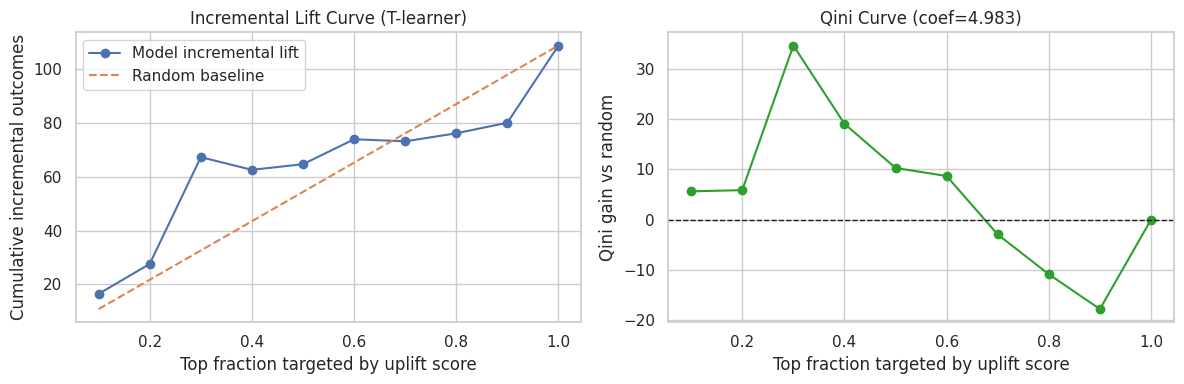

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(uplift_lift_table['top_fraction'], uplift_lift_table['incremental_lift'], marker='o', label='Model incremental lift')
axes[0].plot(uplift_lift_table['top_fraction'], uplift_lift_table['random_incremental_lift'], linestyle='--', label='Random baseline')
axes[0].set_title('Incremental Lift Curve (T-learner)')
axes[0].set_xlabel('Top fraction targeted by uplift score')
axes[0].set_ylabel('Cumulative incremental outcomes')
axes[0].legend()

axes[1].plot(uplift_lift_table['top_fraction'], uplift_lift_table['qini_gain'], marker='o', color='tab:green')
axes[1].axhline(0, color='k', linestyle='--', linewidth=1)
axes[1].set_title(f'Qini Curve (coef={qini_coefficient:.3f})')
axes[1].set_xlabel('Top fraction targeted by uplift score')
axes[1].set_ylabel('Qini gain vs random')

plt.tight_layout()
plt.show()


## Step 11H: Alternative Uplift Learners (S-Learner, X-Learner, Causal Forest)

Below are additional uplift strategies often discussed in advanced discussions.


> **Side note (when to use which):**
> - **S-learner**: simplest operational baseline, one model with treatment as a feature.
> - **X-learner**: often stronger when treatment effects are heterogeneous and treatment/control sizes are imbalanced.
> - **Uplift Trees / Causal Forests**: useful for nonlinearity and interaction-rich treatment effects.


In [30]:
def build_uplift_lift_table(scores, treatment, outcome):
    eval_df = pd.DataFrame(
        {
            'uplift_score': np.asarray(scores),
            'treatment': np.asarray(treatment).astype(int),
            'outcome': np.asarray(outcome).astype(int),
        }
    ).sort_values('uplift_score', ascending=False).reset_index(drop=True)

    rows = []
    for frac in np.arange(0.1, 1.01, 0.1):
        n = max(1, int(len(eval_df) * frac))
        seg = eval_df.head(n)

        treated_seg = seg[seg['treatment'] == 1]
        control_seg = seg[seg['treatment'] == 0]

        treated_rate = treated_seg['outcome'].mean() if len(treated_seg) > 0 else np.nan
        control_rate = control_seg['outcome'].mean() if len(control_seg) > 0 else np.nan

        incremental_lift = (treated_rate - control_rate) * len(seg) if (not np.isnan(treated_rate) and not np.isnan(control_rate)) else np.nan

        rows.append(
            {
                'top_fraction': round(float(frac), 2),
                'segment_size': int(n),
                'treated_rate': treated_rate,
                'control_rate': control_rate,
                'incremental_lift': incremental_lift,
            }
        )

    table = pd.DataFrame(rows)
    table['decile'] = (table['top_fraction'] * 10).astype(int)

    final_incremental_lift = float(table['incremental_lift'].iloc[-1])
    table['random_incremental_lift'] = table['top_fraction'] * final_incremental_lift
    table['qini_gain'] = table['incremental_lift'] - table['random_incremental_lift']
    qini_coefficient = float(np.trapz(table['qini_gain'], table['top_fraction']))

    top20 = eval_df.head(max(1, int(len(eval_df) * 0.20)))
    t20_treated = top20[top20['treatment'] == 1]
    t20_control = top20[top20['treatment'] == 0]
    t20_treated_rate = t20_treated['outcome'].mean() if len(t20_treated) > 0 else np.nan
    t20_control_rate = t20_control['outcome'].mean() if len(t20_control) > 0 else np.nan
    t20_incremental_lift = (t20_treated_rate - t20_control_rate) * len(top20) if (not np.isnan(t20_treated_rate) and not np.isnan(t20_control_rate)) else np.nan
    top20_capture_share = float(t20_incremental_lift / final_incremental_lift) if (not np.isnan(final_incremental_lift) and final_incremental_lift != 0) else np.nan
    top_decile_incremental_lift = float(table.loc[table['decile'] == 1, 'incremental_lift'].iloc[0])

    summary = {
        'top20_segment_size': int(len(top20)),
        'top20_treated_rate': None if np.isnan(t20_treated_rate) else round(float(t20_treated_rate), 4),
        'top20_control_rate': None if np.isnan(t20_control_rate) else round(float(t20_control_rate), 4),
        'top20_incremental_lift': None if np.isnan(t20_incremental_lift) else round(float(t20_incremental_lift), 2),
        'top20_capture_share': None if np.isnan(top20_capture_share) else round(float(top20_capture_share), 4),
        'top_decile_incremental_lift': None if np.isnan(top_decile_incremental_lift) else round(float(top_decile_incremental_lift), 4),
        'qini_coefficient': round(float(qini_coefficient), 4),
    }

    qini_table = table[['top_fraction', 'qini_gain', 'random_incremental_lift']].copy()
    return summary, table, qini_table


### S-learner


> **Beginner note:**
> S-learner is the easiest uplift model to understand:
> - Train one model,
> - Add treatment as an input feature,
> - Predict once as treated and once as control,
> - Subtract the two probabilities.


In [31]:
# One model includes treatment indicator as a feature
X_s_train = X_uplift_train.copy()
X_s_test = X_uplift_test.copy()

X_s_train['treatment_feature'] = T_uplift_train.values

s_learner_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
)

s_learner_model.fit(X_s_train, Y_uplift_train)

X_test_treated = X_s_test.copy()
X_test_control = X_s_test.copy()
X_test_treated['treatment_feature'] = 1
X_test_control['treatment_feature'] = 0

p_treated_s = s_learner_model.predict_proba(X_test_treated)[:, 1]
p_control_s = s_learner_model.predict_proba(X_test_control)[:, 1]
uplift_score_s = p_treated_s - p_control_s

s_summary, s_lift_table, s_qini_table = build_uplift_lift_table(
    uplift_score_s,
    T_uplift_test.values,
    Y_uplift_test.values,
)

print({'model': 'S-learner', **s_summary})
s_lift_table


{'model': 'S-learner', 'top20_segment_size': 281, 'top20_treated_rate': 0.5915, 'top20_control_rate': 0.4676, 'top20_incremental_lift': 34.82, 'top20_capture_share': 0.3202, 'top_decile_incremental_lift': 15.8987, 'qini_coefficient': 15.3773}


,top_fraction,segment_size,treated_rate,control_rate,incremental_lift,decile,random_incremental_lift,qini_gain
0,0.1,140,0.569444,0.455882,15.898693,1,10.873660,5.025033
1,0.2,281,0.591549,0.467626,34.822474,2,21.747321,13.075154
2,0.3,422,0.602871,0.455399,62.233079,3,32.620981,29.612099
3,0.4,562,0.614232,0.488136,70.866298,4,43.494641,27.371657
4,0.5,703,0.644377,0.537433,75.181452,5,54.368301,20.813151
5,0.6,844,0.683673,0.577434,89.666426,6,65.241962,24.424464
6,0.7,984,0.716518,0.626866,88.217751,7,76.115622,12.102129
7,0.8,1125,0.750958,0.661692,100.424601,8,86.989282,13.435319
8,0.9,1266,0.781513,0.695976,108.289146,9,97.862942,10.426203
9,1.0,1407,0.802115,0.724832,108.736603,10,108.736603,0.000000


### X-learner


> **Beginner note:**
> X-learner is more advanced. It learns separate patterns for treated and control groups,
> then combines them into an uplift estimate. Use this when treatment effect varies across customers.


In [32]:
from sklearn.ensemble import RandomForestRegressor

# Stage 1: outcome models for treated and control groups
mu1_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
)

mu0_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
)

mu1_model.fit(X_uplift_train[train_treated_mask], Y_uplift_train[train_treated_mask])
mu0_model.fit(X_uplift_train[train_control_mask], Y_uplift_train[train_control_mask])

# Stage 2: imputed treatment effects
D1 = Y_uplift_train[train_treated_mask].values - mu0_model.predict_proba(X_uplift_train[train_treated_mask])[:, 1]
D0 = mu1_model.predict_proba(X_uplift_train[train_control_mask])[:, 1] - Y_uplift_train[train_control_mask].values

# Stage 3: tau models
tau1_model = RandomForestRegressor(n_estimators=300, random_state=42)
tau0_model = RandomForestRegressor(n_estimators=300, random_state=42)

tau1_model.fit(X_uplift_train[train_treated_mask], D1)
tau0_model.fit(X_uplift_train[train_control_mask], D0)

# Stage 4: combine effects with propensity weight
e_hat = float(T_uplift_train.mean())
tau1_hat = tau1_model.predict(X_uplift_test)
tau0_hat = tau0_model.predict(X_uplift_test)
uplift_score_x = (1 - e_hat) * tau1_hat + e_hat * tau0_hat

x_summary, x_lift_table, x_qini_table = build_uplift_lift_table(
    uplift_score_x,
    T_uplift_test.values,
    Y_uplift_test.values,
)

print({'model': 'X-learner', 'propensity_weight': round(e_hat, 4), **x_summary})
x_lift_table


{'model': 'X-learner', 'propensity_weight': 0.4985, 'top20_segment_size': 281, 'top20_treated_rate': 0.6159, 'top20_control_rate': 0.4895, 'top20_incremental_lift': 35.53, 'top20_capture_share': 0.3267, 'top_decile_incremental_lift': 29.8347, 'qini_coefficient': 7.3992}


,top_fraction,segment_size,treated_rate,control_rate,incremental_lift,decile,random_incremental_lift,qini_gain
0,0.1,140,0.647887,0.434783,29.834660,1,10.873660,18.961000
1,0.2,281,0.615942,0.489510,35.527263,2,21.747321,13.779942
2,0.3,422,0.636364,0.507042,54.573624,3,32.620981,21.952643
3,0.4,562,0.693487,0.574751,66.729497,4,43.494641,23.234856
4,0.5,703,0.711712,0.616216,67.133333,5,54.368301,12.765032
5,0.6,844,0.736181,0.650224,72.547446,6,65.241962,7.305484
6,0.7,984,0.762009,0.692015,68.873628,7,76.115622,-7.241994
7,0.8,1125,0.789773,0.716918,81.961655,8,86.989282,-5.027627
8,0.9,1266,0.805369,0.729851,95.606271,9,97.862942,-2.256672
9,1.0,1407,0.802115,0.724832,108.736603,10,108.736603,0.000000


### Uplift Trees / Causal Forests


> **Beginner note:**
> Causal forests are powerful but optional. If this feels heavy, present T-learner/S-learner first,
> then mention causal forests as an advanced extension.


In [33]:
# Optional: Causal Forest implementation (econml)
# If not installed, use: %pip install econml

try:
    from sklearn.ensemble import RandomForestRegressor
    from econml.dml import CausalForestDML

    cf_model = CausalForestDML(
        model_y=RandomForestRegressor(n_estimators=200, random_state=42),
        model_t=RandomForestRegressor(n_estimators=200, random_state=42),
        n_estimators=500,
        random_state=42,
        discrete_treatment=True,
    )

    cf_model.fit(
        Y_uplift_train.values,
        T_uplift_train.values,
        X=X_uplift_train.values,
    )

    uplift_score_cf = cf_model.effect(X_uplift_test.values)

    cf_summary, cf_lift_table, cf_qini_table = build_uplift_lift_table(
        uplift_score_cf,
        T_uplift_test.values,
        Y_uplift_test.values,
    )

    print({'model': 'CausalForestDML', **cf_summary})
    cf_lift_table

except ModuleNotFoundError:
    print('econml is not installed. Run `%pip install econml` to enable the causal forest section.')


econml is not installed. Run `%pip install econml` to enable the causal forest section.


### Uplift Model Comparison (Actionable Summary)

This block compares uplift learners on the same test split using Qini + top-20% incremental lift.


> **Beginner note:**
> Start with two metrics: **`qini_coefficient`** (overall uplift ranking quality) and
> **`top20_incremental_lift`** (business impact for a fixed budget segment).
>
> **Leakage / overfitting check for uplift:**
> - Make sure treatment assignment and outcome are observed after features (no future leakage).
> - Compare uplift metrics on train vs validation/test splits to monitor overfitting.


In [34]:
# Build comparable summary across uplift learners using uplift-native metrics
comparison_rows = []

# T-learner metrics from Step 11G
if 't20_incremental_lift' in globals():
    comparison_rows.append(
        {
            'model': 'T-learner',
            'qini_coefficient': float(qini_coefficient) if 'qini_coefficient' in globals() else np.nan,
            'top20_incremental_lift': None if np.isnan(t20_incremental_lift) else float(t20_incremental_lift),
            'top20_capture_share': float(top20_capture_share) if 'top20_capture_share' in globals() and not np.isnan(top20_capture_share) else np.nan,
            'top_decile_incremental_lift': float(uplift_lift_table.loc[uplift_lift_table['decile'] == 1, 'incremental_lift'].iloc[0]) if 'uplift_lift_table' in globals() else np.nan,
            'top20_treated_rate': None if np.isnan(t20_treated_rate) else float(t20_treated_rate),
            'top20_control_rate': None if np.isnan(t20_control_rate) else float(t20_control_rate),
        }
    )

# S-learner metrics
if 's_summary' in globals():
    comparison_rows.append(
        {
            'model': 'S-learner',
            'qini_coefficient': s_summary.get('qini_coefficient'),
            'top20_incremental_lift': s_summary.get('top20_incremental_lift'),
            'top20_capture_share': s_summary.get('top20_capture_share'),
            'top_decile_incremental_lift': s_summary.get('top_decile_incremental_lift'),
            'top20_treated_rate': s_summary.get('top20_treated_rate'),
            'top20_control_rate': s_summary.get('top20_control_rate'),
        }
    )

# X-learner metrics
if 'x_summary' in globals():
    comparison_rows.append(
        {
            'model': 'X-learner',
            'qini_coefficient': x_summary.get('qini_coefficient'),
            'top20_incremental_lift': x_summary.get('top20_incremental_lift'),
            'top20_capture_share': x_summary.get('top20_capture_share'),
            'top_decile_incremental_lift': x_summary.get('top_decile_incremental_lift'),
            'top20_treated_rate': x_summary.get('top20_treated_rate'),
            'top20_control_rate': x_summary.get('top20_control_rate'),
        }
    )

# Causal forest metrics (optional)
if 'cf_summary' in globals():
    comparison_rows.append(
        {
            'model': 'CausalForestDML',
            'qini_coefficient': cf_summary.get('qini_coefficient'),
            'top20_incremental_lift': cf_summary.get('top20_incremental_lift'),
            'top20_capture_share': cf_summary.get('top20_capture_share'),
            'top_decile_incremental_lift': cf_summary.get('top_decile_incremental_lift'),
            'top20_treated_rate': cf_summary.get('top20_treated_rate'),
            'top20_control_rate': cf_summary.get('top20_control_rate'),
        }
    )

if len(comparison_rows) == 0:
    print('No uplift summaries found. Run Step 11G/11H cells first.')
else:
    uplift_model_comparison = pd.DataFrame(comparison_rows).sort_values(
        ['qini_coefficient', 'top20_incremental_lift'],
        ascending=[False, False],
        na_position='last',
    )
    display(uplift_model_comparison)

    best_row = uplift_model_comparison.iloc[0]
    print(
        {
            'recommended_uplift_model': best_row['model'],
            'recommended_qini': best_row['qini_coefficient'],
            'recommended_top20_incremental_lift': best_row['top20_incremental_lift'],
            'recommended_top20_capture_share': best_row['top20_capture_share'],
        }
    )

    print('Targeting policy: score users by uplift, prioritize top deciles, and cap outreach by campaign budget/CLV constraints.')


,model,qini_coefficient,top20_incremental_lift,top20_capture_share,top_decile_incremental_lift,top20_treated_rate,top20_control_rate
1,S-learner,15.377300,34.820000,0.320200,15.898700,0.591500,0.4676
2,X-learner,7.399200,35.530000,0.326700,29.834700,0.615900,0.4895
0,T-learner,4.982787,27.628092,0.254083,16.511057,0.618321,0.5200


{'recommended_uplift_model': 'S-learner', 'recommended_qini': 15.3773, 'recommended_top20_incremental_lift': 34.82, 'recommended_top20_capture_share': 0.3202}
Targeting policy: score users by uplift, prioritize top deciles, and cap outreach by campaign budget/CLV constraints.


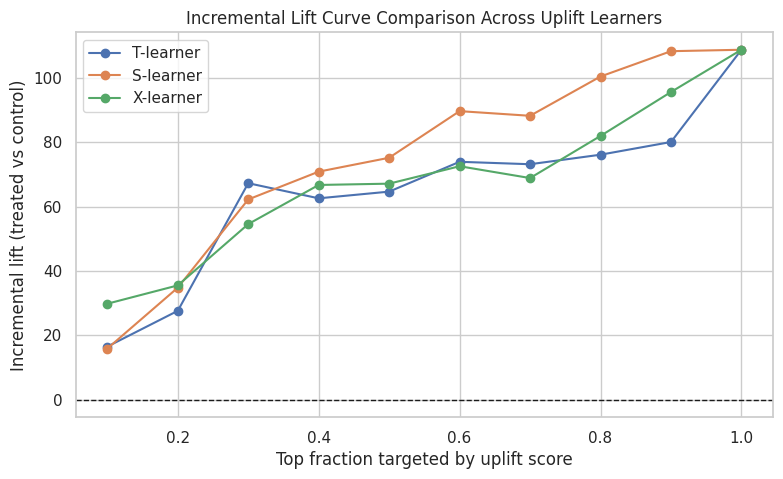

In [35]:
# Overlay lift curves across uplift learners (if available)
plt.figure(figsize=(9, 5))

plotted = 0
if 'uplift_lift_table' in globals() and not uplift_lift_table.empty:
    plt.plot(
        uplift_lift_table['top_fraction'],
        uplift_lift_table['incremental_lift'],
        marker='o',
        label='T-learner',
    )
    plotted += 1

if 's_lift_table' in globals() and not s_lift_table.empty:
    plt.plot(
        s_lift_table['top_fraction'],
        s_lift_table['incremental_lift'],
        marker='o',
        label='S-learner',
    )
    plotted += 1

if 'x_lift_table' in globals() and not x_lift_table.empty:
    plt.plot(
        x_lift_table['top_fraction'],
        x_lift_table['incremental_lift'],
        marker='o',
        label='X-learner',
    )
    plotted += 1

if 'cf_lift_table' in globals() and isinstance(cf_lift_table, pd.DataFrame) and not cf_lift_table.empty:
    plt.plot(
        cf_lift_table['top_fraction'],
        cf_lift_table['incremental_lift'],
        marker='o',
        label='CausalForestDML',
    )
    plotted += 1

if plotted == 0:
    print('No lift tables found. Run Step 11G and Step 11H first.')
else:
    plt.axhline(0, color='k', linestyle='--', linewidth=1)
    plt.title('Incremental Lift Curve Comparison Across Uplift Learners')
    plt.xlabel('Top fraction targeted by uplift score')
    plt.ylabel('Incremental lift (treated vs control)')
    plt.legend()
    plt.show()


## Step 12: MLflow Tracking And Model Registry

This section shows how to track the experiment, log metrics and artifacts, and register a model version. For local use, you can keep the file-based tracking URI or point it to a dedicated MLflow server.


In [36]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

mlflow.set_tracking_uri("file:///opt/spark/notebooks/experiments/mlruns")
mlflow.set_experiment("telco-customer-churn")

sample_input = X_test.head(5)
sample_output = lr_model.predict(sample_input)
signature = infer_signature(sample_input, sample_output)

with mlflow.start_run(run_name="churn-model-evaluation"):
    mlflow.log_param("model_type", "logistic_regression")
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("threshold", float(final_scoring_threshold if 'final_scoring_threshold' in globals() else threshold))
    mlflow.log_param("scoring_model_used", final_scoring_label if 'final_scoring_label' in globals() else 'xgb_unknown')
    mlflow.log_param("uplift_data_source", uplift_data_source if 'uplift_data_source' in globals() else 'not_computed')
    mlflow.log_param("uplift_demo_only", bool(is_uplift_demo_only) if 'is_uplift_demo_only' in globals() else False)
    mlflow.log_metric("lr_roc_auc", roc_auc_score(y_test, y_pred_proba_lr))
    mlflow.log_metric("xgb_roc_auc", roc_auc_score(y_test, final_scoring_proba if 'final_scoring_proba' in globals() else y_pred_proba_xgb))
    mlflow.log_metric("profit_at_threshold", float(best_profit if 'best_profit' in globals() else profit))
    if 'capture_rate' in globals():
        mlflow.log_metric("risk_top20_capture_rate", float(capture_rate))
    mlflow.log_dict(threshold_results, "artifacts/threshold_scan.json")

    mlflow.sklearn.log_model(
        sk_model=lr_model,
        artifact_path="model",
        signature=signature,
        input_example=sample_input,
        registered_model_name="telco_customer_churn_lr",
    )

print("MLflow run logged. Registered model name: telco_customer_churn_lr")


Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
2026/04/24 06:07:45 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE


Registered model 'telco_customer_churn_lr' already exists. Creating a new version of this model...
Created version '13' of model 'telco_customer_churn_lr'.


MLflow run logged. Registered model name: telco_customer_churn_lr


## Step 13: Weights & Biases

Use this if you want hosted experiment tracking. The W&B dashboard is hosted at [https://wandb.ai](https://wandb.ai), not inside this Docker stack.

Typical flow:
1. Set `WANDB_API_KEY` from a hidden prompt using `getpass`, or export it before starting Jupyter.
2. Start a run with `wandb.init(...)`.
3. Log your churn metrics and business profit.
4. Open the project or run URL printed by the notebook.

Leave this section commented until you are ready to authenticate with your W&B account.


In [37]:
# import wandb
#
# import getpass
# import os
#
# # Capture the API key without echoing it into notebook output.
# if not os.environ.get("WANDB_API_KEY"):
#     os.environ["WANDB_API_KEY"] = getpass.getpass("Enter your W&B API key: ")
#
# run = wandb.init(
#     project="telco-customer-churn",
#     entity=None,  # Replace with your W&B team or username if needed.
#     job_type="training",
#     tags=["marketing", "churn", "xgboost"],
#     config={
#         "threshold": threshold,
#         "xgb_n_estimators": 200,
#         "xgb_max_depth": 4,
#     },
# )
#
# wandb.log(
#     {
#         "lr_roc_auc": roc_auc_score(y_test, y_pred_proba_lr),
#         "xgb_roc_auc": roc_auc_score(y_test, y_pred_proba_xgb),
#         "xgb_pr_auc": average_precision_score(y_test, y_pred_proba_xgb),
#         "profit": profit,
#     }
# )
#
# print("Project page:", f"https://wandb.ai/{run.entity}/{run.project}")
# print("Run page:", run.url)
#
# wandb.finish()


## Step 14: Evidently Monitoring Snapshot

A lightweight way to generate a data-quality or drift report. Here we compare the training set against the scored test set.


In [38]:
from evidently import Report
from evidently.presets import DataDriftPreset

reference_data = X_train.copy()
current_data = X_test.copy()

drift_report = Report([DataDriftPreset()])
drift_snapshot = drift_report.run(reference_data=reference_data, current_data=current_data)
drift_snapshot.save_html("reports/telco_churn_evidently_report.html")

print("Saved Evidently report to reports/telco_churn_evidently_report.html")


Saved Evidently report to reports/telco_churn_evidently_report.html


## Step 15: WhyLogs And WhyLabs

Use `whylogs` for local logging and optionally send profiles to WhyLabs by configuring your API credentials.


In [39]:
import whylogs as why
from whylogs.api.writer.local import LocalWriter

scored_df = X_test.copy()
scored_df["prediction_score"] = y_pred_proba_xgb
scored_df["prediction_label"] = y_pred

profile = why.log(scored_df).profile()
writer = LocalWriter(base_dir="artifacts", base_name="telco_churn_profile.bin")
writer.write(profile)

print("Saved WhyLogs profile to artifacts/telco_churn_profile.bin")

# Optional WhyLabs upload example
# from whylabs_client import ApiClient, Configuration
# from whylogs.api.writer.whylabs import WhyLabsWriter
#
# writer = WhyLabsWriter()
# writer.write(profile.view())


Saved WhyLogs profile to artifacts/telco_churn_profile.bin


## Step 16: FastAPI Scoring Contract

The local stack now includes a FastAPI starter app on `localhost:8000`. This example payload shows the kind of JSON contract you can build around the churn model.


In [40]:
example_payload = X_test.head(1).to_dict(orient="records")
example_payload


[{'gender': 'Female',
  'SeniorCitizen': 0,
  'Partner': 'Yes',
  'Dependents': 'Yes',
  'tenure': 59,
  'PhoneService': 'Yes',
  'MultipleLines': 'No',
  'InternetService': 'DSL',
  'OnlineSecurity': 'No',
  'OnlineBackup': 'Yes',
  'DeviceProtection': 'No',
  'TechSupport': 'Yes',
  'StreamingTV': 'Yes',
  'StreamingMovies': 'Yes',
  'Contract': 'Two year',
  'PaperlessBilling': 'Yes',
  'PaymentMethod': 'Credit card (automatic)',
  'MonthlyCharges': 75.95,
  'TotalCharges': 4542.35}]

In [41]:
import requests

try:
    response = requests.post("http://localhost:8000/predict", json=example_payload, timeout=10)
    print({'status_code': response.status_code, 'response_json': response.json()})
except Exception as e:
    print(f'API test skipped: {e}')


API test skipped: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /predict (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0xffff449c4a00>: Failed to establish a new connection: [Errno 111] Connection refused'))


## Final Story

I built a churn prediction workflow for a marketing retention use case and linked model outputs to business action.

- Started with **Logistic Regression** as an interpretable baseline, then trained **XGBoost** for stronger nonlinear performance.
- Handled class imbalance explicitly using **`scale_pos_weight`**, and evaluated with both **ROC-AUC** and **PR-AUC**.
- Improved probability quality with **calibration** (isotonic) and validated with **Brier score** + calibration curve.
- Optimized decision thresholds with a **business cost/profit framework** instead of default `0.5`.
- Added **risk segmentation** to measure how many churners are captured in the top 20% highest-risk customers.
- Used **SHAP** and feature importance for explainability, and documented **leakage checks** plus **train-test AUC gap** for overfitting control.
- Added **uplift modeling (T-learner)** to estimate incremental treatment effect and prioritize customers most likely to change behavior with outreach.
- Benchmarked multiple uplift approaches (**T-learner, S-learner, X-learner, and optional causal forest**) to estimate incremental treatment effect under budget constraints.

This turns churn modeling from a pure prediction task into an operational retention strategy.


## Diagnostics: Log Loss + Learning Curve

These two plots help us validate probability quality and data-size behavior.

- Log loss plot: compares probability quality across available model score outputs.
- Learning curve: shows train vs validation log loss as training size grows.


/tmp/ipykernel_5281/1403501944.py:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




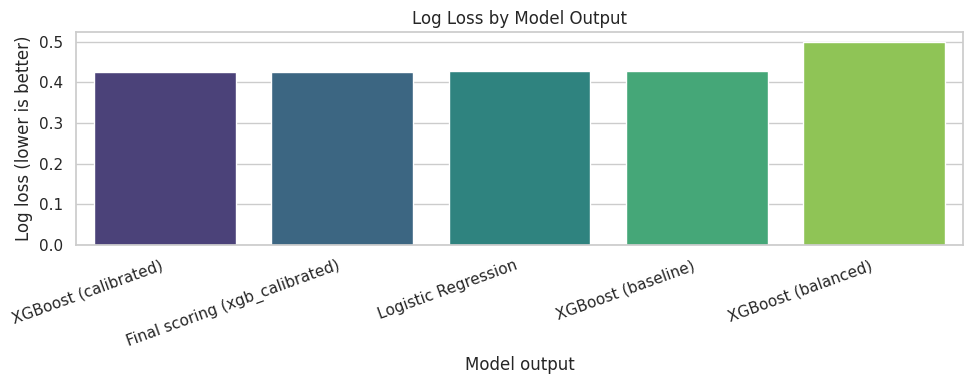

,model,log_loss
0,XGBoost (calibrated),0.424361
1,Final scoring (xgb_calibrated),0.424361
2,Logistic Regression,0.427308
3,XGBoost (baseline),0.427457
4,XGBoost (balanced),0.498344


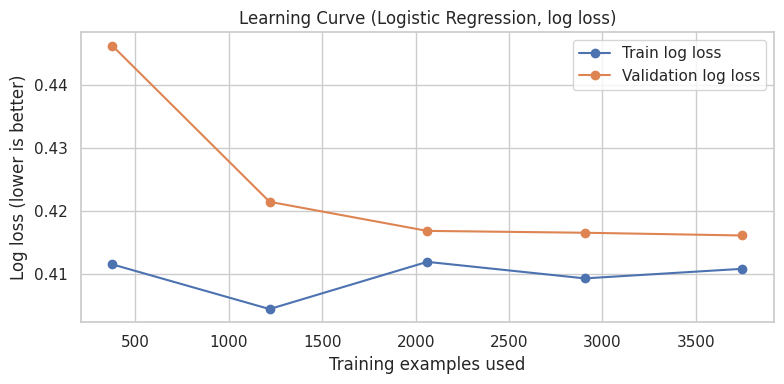

In [42]:
# Side note (beginner): lower log loss is better.
# A smaller gap between train and validation curves usually means better generalization.

from sklearn.metrics import log_loss
from sklearn.model_selection import learning_curve
from sklearn.base import clone

if 'y_test' not in globals():
    print('y_test not found. Run model training cells first.')
else:
    proba_candidates = []
    if 'y_pred_proba_lr' in globals():
        proba_candidates.append(('Logistic Regression', y_pred_proba_lr))
    if 'y_pred_proba_xgb' in globals():
        proba_candidates.append(('XGBoost (baseline)', y_pred_proba_xgb))
    if 'y_pred_proba_xgb_balanced' in globals():
        proba_candidates.append(('XGBoost (balanced)', y_pred_proba_xgb_balanced))
    if 'y_pred_proba_xgb_calibrated' in globals():
        proba_candidates.append(('XGBoost (calibrated)', y_pred_proba_xgb_calibrated))
    if 'final_scoring_proba' in globals() and 'final_scoring_label' in globals():
        proba_candidates.append((f'Final scoring ({final_scoring_label})', final_scoring_proba))

    if proba_candidates:
        logloss_df = pd.DataFrame([
            {'model': name, 'log_loss': float(log_loss(y_test, probs))}
            for name, probs in proba_candidates
        ]).drop_duplicates(subset='model').sort_values('log_loss', ascending=True)

        plt.figure(figsize=(10, 4))
        sns.barplot(data=logloss_df, x='model', y='log_loss', palette='viridis')
        plt.title('Log Loss by Model Output')
        plt.xlabel('Model output')
        plt.ylabel('Log loss (lower is better)')
        plt.xticks(rotation=20, ha='right')
        plt.tight_layout()
        plt.show()
        display(logloss_df.reset_index(drop=True))
    else:
        print('No probability predictions found for log loss plot.')

    if all(v in globals() for v in ['lr_model', 'X_train', 'y_train']):
        train_sizes = np.linspace(0.1, 1.0, 5)
        sizes, train_scores, valid_scores = learning_curve(
            estimator=clone(lr_model),
            X=X_train,
            y=y_train,
            cv=3,
            scoring='neg_log_loss',
            train_sizes=train_sizes,
            n_jobs=1,
            shuffle=True,
            random_state=42,
        )

        train_loss = -train_scores.mean(axis=1)
        valid_loss = -valid_scores.mean(axis=1)

        plt.figure(figsize=(8, 4))
        plt.plot(sizes, train_loss, marker='o', label='Train log loss')
        plt.plot(sizes, valid_loss, marker='o', label='Validation log loss')
        plt.title('Learning Curve (Logistic Regression, log loss)')
        plt.xlabel('Training examples used')
        plt.ylabel('Log loss (lower is better)')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print('Learning curve skipped: lr_model / X_train / y_train not found.')


## Step 11I: Real-World Uplift Validation (Hillstrom Email Campaign)

Client question: **Did campaign actually work?**

Beginner side notes:
- We use the real Hillstrom campaign dataset.
- Treatment = customer received marketing email (`segment != 'No E-Mail`).
- Outcome = conversion event.
- We evaluate uplift ranking with decile analysis and Qini-style gain.
- This is closer to real measurement than plain conversion prediction.


{'data_source': 'data/hillstrom_email_campaign.csv', 'rows': 64000, 'treated_rate': 0.6671, 'conversion_rate': 0.009}


,model,qini_coefficient,top20_treated_rate,top20_control_rate,top20_incremental_lift
0,T-learner,52.768795,0.056595,0.022599,108.787451
1,X-learner,7.170554,0.029504,0.012461,54.536770


T-learner deciles:


,decile,n,treated_rate,outcome_rate,avg_uplift_score
0,1,1600,0.687500,0.090625,0.027408
1,2,1600,0.648750,0.000000,0.000418
2,3,1600,0.659375,0.000000,0.000128
3,4,1600,0.670625,0.000000,-0.000036
4,5,1600,0.651875,0.000000,-0.000183
5,6,1600,0.665000,0.000000,-0.000368
6,7,1600,0.654375,0.000000,-0.000614
7,8,1600,0.665625,0.000000,-0.001026
8,9,1600,0.670625,0.000000,-0.002257
9,10,1600,0.758750,0.000000,-0.014124


X-learner deciles:


,decile,n,treated_rate,outcome_rate,avg_uplift_score
0,1,1600,0.726250,0.039375,0.004434
1,2,1600,0.671875,0.009375,0.000572
2,3,1600,0.674375,0.003125,0.000256
3,4,1600,0.644375,0.001250,0.000143
4,5,1600,0.665000,0.001875,0.000072
5,6,1600,0.678125,0.000625,0.000015
6,7,1600,0.635625,0.000000,-0.000043
7,8,1600,0.672500,0.000000,-0.000117
8,9,1600,0.665000,0.000000,-0.000245
9,10,1600,0.699375,0.035000,-0.001125


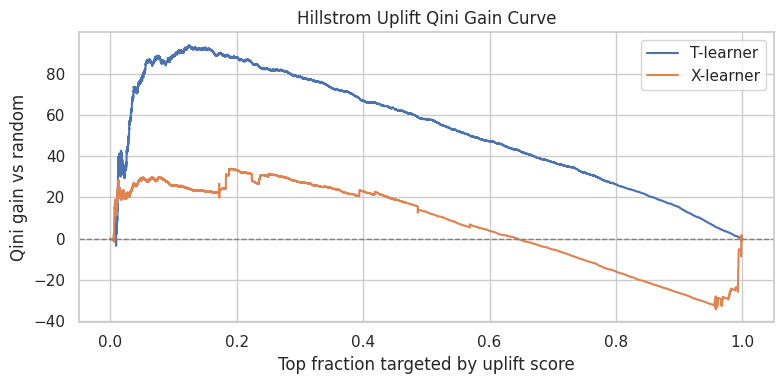

In [43]:
# Side note (beginner): this section runs independently from the telco data.

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

hillstrom_paths = [
    Path('data/hillstrom_email_campaign.csv'),
    Path('/opt/spark/notebooks/data/hillstrom_email_campaign.csv'),
]
hillstrom_path = next((p for p in hillstrom_paths if p.exists()), None)
if hillstrom_path is None:
    raise FileNotFoundError('Hillstrom CSV not found. Expected data/hillstrom_email_campaign.csv')

hill = pd.read_csv(hillstrom_path)

# Treatment and outcome definitions.
hill['treatment'] = (hill['segment'].astype(str) != 'No E-Mail').astype(int)
hill['outcome'] = hill['conversion'].astype(int)

feature_drop = ['segment', 'conversion', 'spend']
Xh = hill.drop(columns=[c for c in feature_drop if c in hill.columns]).copy()
Th = hill['treatment'].values
Yh = hill['outcome'].values

Xh = pd.get_dummies(Xh, drop_first=True)

X_train_h, X_test_h, T_train_h, T_test_h, Y_train_h, Y_test_h = train_test_split(
    Xh, Th, Yh, test_size=0.25, random_state=42, stratify=Yh
)


def uplift_lift_qini_table(score, treatment, outcome):
    d = pd.DataFrame({'uplift_score': score, 'treatment': treatment, 'outcome': outcome}).sort_values('uplift_score', ascending=False).reset_index(drop=True)
    d['rank'] = np.arange(1, len(d) + 1)
    d['top_fraction'] = d['rank'] / len(d)

    d['cum_treated'] = d['treatment'].cumsum()
    d['cum_control'] = ((1 - d['treatment'])).cumsum()
    d['cum_y_treated'] = (d['outcome'] * d['treatment']).cumsum()
    d['cum_y_control'] = (d['outcome'] * (1 - d['treatment'])).cumsum()

    d['treated_rate'] = np.where(d['cum_treated'] > 0, d['cum_y_treated'] / d['cum_treated'], np.nan)
    d['control_rate'] = np.where(d['cum_control'] > 0, d['cum_y_control'] / d['cum_control'], np.nan)
    d['incremental_lift'] = (d['treated_rate'] - d['control_rate']) * d['rank']

    final_inc = float(d['incremental_lift'].iloc[-1])
    d['random_incremental_lift'] = d['top_fraction'] * final_inc
    d['qini_gain'] = d['incremental_lift'] - d['random_incremental_lift']

    qini_coeff = float(np.trapz(d['qini_gain'].fillna(0).values, d['top_fraction'].values))

    d['decile'] = np.ceil(d['top_fraction'] * 10).astype(int)
    dec = d.groupby('decile').agg(
        n=('outcome', 'size'),
        treated_rate=('treatment', 'mean'),
        outcome_rate=('outcome', 'mean'),
        avg_uplift_score=('uplift_score', 'mean'),
    ).reset_index()

    top20 = d[d['top_fraction'] <= 0.20]
    top20_t = top20[top20['treatment'] == 1]['outcome'].mean()
    top20_c = top20[top20['treatment'] == 0]['outcome'].mean()

    summary = {
        'qini_coefficient': qini_coeff,
        'top20_treated_rate': float(top20_t) if pd.notna(top20_t) else np.nan,
        'top20_control_rate': float(top20_c) if pd.notna(top20_c) else np.nan,
        'top20_incremental_lift': float((top20_t - top20_c) * len(top20)) if pd.notna(top20_t) and pd.notna(top20_c) else np.nan,
    }
    return d, dec, summary


# --- T-learner ---
m_t = RandomForestClassifier(n_estimators=200, random_state=42, min_samples_leaf=40, n_jobs=1)
m_c = RandomForestClassifier(n_estimators=200, random_state=42, min_samples_leaf=40, n_jobs=1)
m_t.fit(X_train_h[T_train_h == 1], Y_train_h[T_train_h == 1])
m_c.fit(X_train_h[T_train_h == 0], Y_train_h[T_train_h == 0])
p1_t = m_t.predict_proba(X_test_h)[:, 1]
p0_t = m_c.predict_proba(X_test_h)[:, 1]
uplift_t = p1_t - p0_t
t_curve, t_decile, t_summary = uplift_lift_qini_table(uplift_t, T_test_h, Y_test_h)

# --- X-learner ---
mu1 = RandomForestClassifier(n_estimators=200, random_state=42, min_samples_leaf=40, n_jobs=1)
mu0 = RandomForestClassifier(n_estimators=200, random_state=42, min_samples_leaf=40, n_jobs=1)
mu1.fit(X_train_h[T_train_h == 1], Y_train_h[T_train_h == 1])
mu0.fit(X_train_h[T_train_h == 0], Y_train_h[T_train_h == 0])

D1 = Y_train_h[T_train_h == 1] - mu0.predict_proba(X_train_h[T_train_h == 1])[:, 1]
D0 = mu1.predict_proba(X_train_h[T_train_h == 0])[:, 1] - Y_train_h[T_train_h == 0]

tau1 = RandomForestRegressor(n_estimators=200, random_state=42, min_samples_leaf=40, n_jobs=1)
tau0 = RandomForestRegressor(n_estimators=200, random_state=42, min_samples_leaf=40, n_jobs=1)
tau1.fit(X_train_h[T_train_h == 1], D1)
tau0.fit(X_train_h[T_train_h == 0], D0)

e_hat = float(T_train_h.mean())
uplift_x = (1 - e_hat) * tau1.predict(X_test_h) + e_hat * tau0.predict(X_test_h)
x_curve, x_decile, x_summary = uplift_lift_qini_table(uplift_x, T_test_h, Y_test_h)

hillstrom_uplift_comparison = pd.DataFrame([
    {'model': 'T-learner', **t_summary},
    {'model': 'X-learner', **x_summary},
]).sort_values(['qini_coefficient', 'top20_incremental_lift'], ascending=False)

print({'data_source': str(hillstrom_path), 'rows': int(len(hill)), 'treated_rate': round(float(hill['treatment'].mean()), 4), 'conversion_rate': round(float(hill['outcome'].mean()), 4)})
display(hillstrom_uplift_comparison)
print('T-learner deciles:')
display(t_decile)
print('X-learner deciles:')
display(x_decile)

plt.figure(figsize=(8, 4))
plt.plot(t_curve['top_fraction'], t_curve['qini_gain'].fillna(0), label='T-learner')
plt.plot(x_curve['top_fraction'], x_curve['qini_gain'].fillna(0), label='X-learner')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Hillstrom Uplift Qini Gain Curve')
plt.xlabel('Top fraction targeted by uplift score')
plt.ylabel('Qini gain vs random')
plt.legend()
plt.tight_layout()
plt.show()

uplift_data_source = 'hillstrom_real_world'
is_uplift_demo_only = False


## Quick Verify Checklist (Run Before Sharing)

Run this once after all modeling cells to confirm final metrics and metadata are aligned.


In [44]:
from pathlib import Path

summary = {}
summary['scoring_model_used'] = globals().get('final_scoring_label', 'not_set')

proba = globals().get(
    'final_scoring_proba',
    globals().get(
        'y_pred_proba_xgb_calibrated',
        globals().get('y_pred_proba_xgb_balanced', globals().get('y_pred_proba_xgb', None)),
    ),
)

if proba is not None and 'y_test' in globals():
    summary['xgb_roc_auc'] = round(float(roc_auc_score(y_test, proba)), 4)
else:
    summary['xgb_roc_auc'] = 'not_computed'

summary['best_threshold'] = globals().get(
    'final_scoring_threshold',
    globals().get('best_threshold', globals().get('threshold', 'not_set')),
)
summary['best_profit'] = globals().get('best_profit', globals().get('profit', 'not_set'))
summary['risk_top20_capture_rate'] = (
    round(float(globals().get('capture_rate')), 4) if 'capture_rate' in globals() else 'not_set'
)
summary['uplift_data_source'] = globals().get('uplift_data_source', 'not_computed')
summary['uplift_demo_only'] = bool(globals().get('is_uplift_demo_only', False))

if 'mlflow' in globals():
    summary['mlflow_tracking_uri'] = mlflow.get_tracking_uri()
    try:
        exp = mlflow.get_experiment_by_name('telco-customer-churn')
        summary['mlflow_experiment'] = exp.experiment_id if exp else 'not_found'
    except Exception as e:
        summary['mlflow_experiment'] = f'error: {e}'
else:
    summary['mlflow_tracking_uri'] = 'mlflow_not_imported'
    summary['mlflow_experiment'] = 'unknown'

mlruns_path = Path('/opt/spark/notebooks/experiments/mlruns')
summary['mlruns_path_exists'] = mlruns_path.exists()

print('=== QUICK VERIFY CHECKLIST ===')
for k, v in summary.items():
    print(f'{k}: {v}')


=== QUICK VERIFY CHECKLIST ===
scoring_model_used: xgb_calibrated
xgb_roc_auc: 0.8368
best_threshold: 0.1
best_profit: 27550.0
risk_top20_capture_rate: 0.492
uplift_data_source: hillstrom_real_world
uplift_demo_only: False
mlflow_tracking_uri: file:///opt/spark/notebooks/experiments/mlruns
mlflow_experiment: 559037503512253843
mlruns_path_exists: True
